# Regressione lineare

Il modello di regressione lineare semplice è uno degli strumenti più intuitivi e fondamentali della statistica predittiva, utilizzato per studiare e quantificare la relazione lineare tra due variabili. La sua essenza è racchiusa nell'equazione di una retta: 

$$y = mx + q$$ 

dove: 
* **$y$** rappresenta la variabile dipendente (ciò che vogliamo prevedere)
* **$x$** è la variabile indipendente (il predittore)
* **$m$** è il coefficiente angolare (o pendenza) che indica di quanto varia **$y$** per ogni incremento unitario di **$x$**
* **$q$** è l'intercetta, ovvero il valore teorico di **$y$** quando **$x$** è pari a zero.
  
   Se adottiamo questa formula per prevedere lo stipendio di un individuo in base alla sua esperienza lavorativa, sostituiamo **$y$** con **$Salary$** (stipendio) e **$x$** con **$Years\_Exp$** (anni di esperienza), ottenendo la relazione:

$$
Salary = m \cdot Years\_Exp + q
$$

In questo specifico contesto, il coefficiente **$m$** assume un significato particolarmente rilevante, poiché rappresenta l'incremento salariale medio atteso per ogni anno aggiuntivo di esperienza maturata (ad esempio, se $m = 200$, significa che per ogni anno in più di lavoro lo stipendio aumenta in media di $200$ euro), mentre **$q$** rappresenta lo stipendio base teorico per un neoassunto con zero anni di esperienza. 

L'obiettivo del modello, che viene tipicamente stimato tramite il metodo dei **minimi quadrati ordinari (OLS)**, è proprio quello di trovare i valori ottimali di **$m$** e **$q$** che minimizzino la distanza (l'errore) tra i valori stipendiali effettivamente osservati e quelli previsti dalla retta, offrendo così uno strumento semplice ma potente per fare previsioni e comprendere le dinamiche del mercato del lavoro.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
np.random.seed(42)

# noise = 350
# N = 30

# years_exp = np.random.randint(0,15,50)
# salary = years_exp * 200 + 1300 + np.random.normal(0,noise,50)

# df = pd.DataFrame(
#     {
#         'years_exp': years_exp,
#         'salary': salary
#     }
# )

# file_path = 'dataset_hr.xlsx'
# df.to_excel(file_path, index=False)


file_path = 'dataset_hr_train.xlsx'
df = pd.read_excel(file_path)

print(f'Dimensioni tabella: {df.shape}')
df.head()



Dimensioni tabella: (50, 2)


,years_exp,salary
0,6,2549.862611
1,3,1887.871736
2,12,4097.018743
3,14,4063.339058
4,10,3116.207002


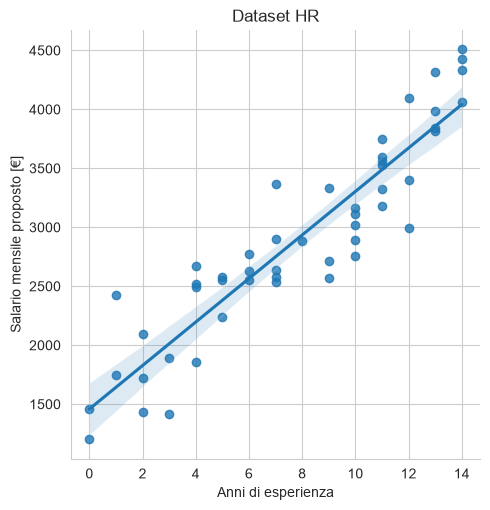

In [2]:

sns.lmplot(df,x='years_exp',y='salary')
plt.title('Dataset HR')
plt.xlabel('Anni di esperienza')
plt.ylabel('Salario mensile proposto [€]')
plt.show()

## Un modello fatto "A mano"

L'equazione di una retta che passa per due punti $(x_1,y_1)$ ed $(x_2,y_2)$:
$$
y = mx + q
$$

Per calcolare i due parametri $m$ (coefficiente angolare) e $q$ (intercetta) dobbiamo effettuare le seguenti operazioni:

$$
m = \frac{y_2 - y_1}{x_2 - x_1}
$$
$$
q = y_1 - m x_1
$$



In [3]:
x_graphic = (0,14)
y_graphic = (1500,4500)


def retta_da_due_punti(x, y):
    x1,x2 = x[0],x[1]
    y1,y2 = y[0],y[1]
    
    if x1 == x2:
        return None, x1  # retta verticale
    m = (y2 - y1) / (x2 - x1)
    q = y1 - m * x1
    return (m,q)

# Esempio
(m,q) = retta_da_due_punti(x_graphic, y_graphic)
print(f'y = {m:.2f}x + {q:.2f}')

y = 214.29x + 1500.00


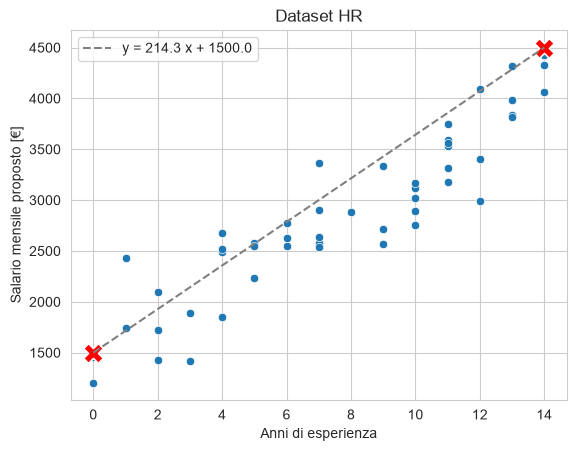

In [4]:


sns.scatterplot(df,x='years_exp',y='salary')
sns.scatterplot(x=x_graphic,y=y_graphic,marker='X', color='red',s=200)
sns.lineplot(x=x_graphic,y=y_graphic,linestyle='--', color='gray',label=f'y = {m:.1f} x + {q:.1f}')
plt.legend()
plt.title('Dataset HR')
plt.xlabel('Anni di esperienza')
plt.ylabel('Salario mensile proposto [€]')
plt.show()

Proviamo ad effettuare delle previsioni su alcuni dati importati.

In [5]:
file_path = 'dataset_hr_predictions.xlsx'
df_predictions = pd.read_excel(file_path)

years_new = df_predictions['years_exp'].to_numpy()

salary_new = years_new * m + q

new_data = pd.DataFrame(
    {
        'years_exp': years_new,
        'salary': salary_new
    }
)

new_data

,years_exp,salary
0,4,2357.142857
1,2,1928.571429
2,10,3642.857143
3,11,3857.142857
4,7,3000.000000
5,6,2785.714286


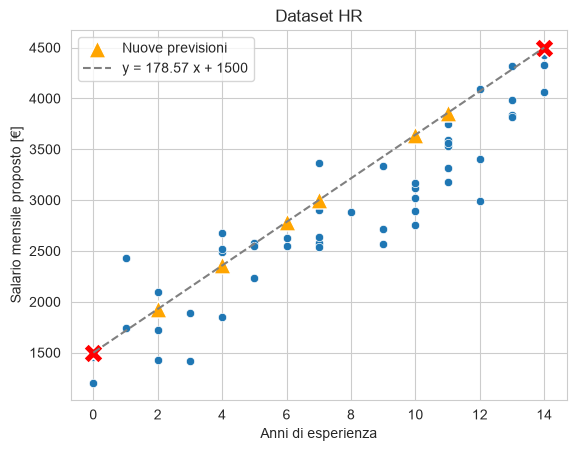

In [6]:
sns.scatterplot(df,x='years_exp',y='salary')
sns.scatterplot(x=x_graphic,y=y_graphic,marker='X', color='red',s=200)
sns.scatterplot(x=years_new,y=salary_new,marker='^', color='orange',s=150,label='Nuove previsioni')
sns.lineplot(x=x_graphic,y=y_graphic,linestyle='--', color='gray',label='y = 178.57 x + 1500')
plt.legend()
plt.title('Dataset HR')
plt.xlabel('Anni di esperienza')
plt.ylabel('Salario mensile proposto [€]')
plt.show()

Valutiamo il modello sui dati reali. Utilizzeremo tre metriche:

**RMSE (Root Mean Squared Error) - Errore Quadratico Medio Radice**
- Misura l'errore medio di previsione in unità della variabile dipendente.
- Calcola la radice quadrata della media dei quadrati dei residui:  
  $$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$
- **Penalizza in modo pesante gli errori grandi** (grazie all'elevazione al quadrato), rendendolo sensibile ai valori anomali (*outlier*).
- È interpretabile nella stessa unità di misura di **$y$** (ad esempio, euro se si prevedono stipendi).
- Più il valore è basso, migliore è la capacità predittiva del modello.

**MAE (Mean Absolute Error) - Errore Assoluto Medio**
- Misura l'errore medio di previsione senza amplificare gli errori grandi.
- Calcola la media dei valori assoluti dei residui:  
  $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
- **Tratta tutti gli errori in modo lineare**, rendendolo meno sensibile agli *outlier* rispetto all'RMSE.
- È interpretabile nella stessa unità di misura di **$y$**, ed è spesso preferito quando si vogliono evitare distorsioni dovute a valori estremi.
- Più il valore è basso, migliore è la precisione media delle previsioni.

**R² (Coefficiente di Determinazione)**
- Misura la **bontà di adattamento** del modello, ovvero quanta parte della variabilità totale di **$y$** viene spiegata dal modello.
- Si calcola come:  
  $$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$  
  dove il numeratore è la somma dei quadrati dei residui (SSR) e il denominatore è la somma dei quadrati totali (SST).
- Assume valori compresi tra **0 e 1** (anche se in casi particolari può essere negativo, indicando un modello peggiore della media).
- **Un R² vicino a 1** indica che il modello spiega gran parte della variabilità dei dati; **vicino a 0** indica che il modello non spiega quasi nulla.
- **Non indica la bontà assoluta** del modello: un R² elevato non garantisce che le previsioni siano accurate, né che il modello sia corretto (può nascondere overfitting o relazioni non lineari).

In [7]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

x_train = df['years_exp'].to_numpy()
y_train = df['salary'].to_numpy()
y_pred_g = m * x_train + q

def stampa_report_modello(y,yp):
    print(f'MAE: {mean_absolute_error(y,yp):.2f}')
    print(f'RMSE: {root_mean_squared_error(y,yp):.2f}')
    print(f'R^2 Score: {r2_score(y,yp):.2f}')

stampa_report_modello(y_train,y_pred_g)

MAE: 354.05
RMSE: 441.50
R^2 Score: 0.72


## Un modello fatto in modo matematico

Per determinare i valori ottimali di **$m$** e **$q$** che rendono la retta di regressione il più possibile aderente ai dati osservati, si utilizza il metodo dei minimi quadrati ordinari (*Ordinary Least Squares*, OLS). L'idea di fondo è quella di minimizzare la somma dei quadrati dei residui, dove ciascun residuo è la differenza tra il valore osservato **$y_i$** e il valore previsto **$\hat{y}_i = m x_i + q$** per l'$i$-esima osservazione. Formalmente, si minimizza la funzione di costo:

$$
S(m, q) = \sum_{i=1}^{n} \left( y_i - (m x_i + q) \right)^2
$$

dove **$n$** è il numero totale di osservazioni nel campione. Derivando parzialmente questa funzione rispetto a **$m$** e a **$q$** e uguagliando a zero le derivate, si ottiene un sistema di due equazioni lineari (dette *equazioni normali*) la cui soluzione fornisce le stime cercate. La pendenza **$m$** si calcola come:

$$
m = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

dove:

$$
\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i \quad \text{e} \quad \bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i
$$

sono rispettivamente le medie campionarie di **$x$** e di **$y$**, ovvero le coordinate del baricentro (o centro di massa) dei dati, denotato come **$(\bar{x}, \bar{y})$**. Questa formula esprime il rapporto tra la covarianza tra **$x$** e **$y$** e la varianza di **$x$**, ed è proprio questo rapporto che garantisce la retta con la minor somma di errori quadratici. Una volta ottenuto **$m$**, l'intercetta **$q$** viene calcolata per differenza, imponendo il passaggio della retta per il baricentro dei dati **$(\bar{x}, \bar{y})$**:

$$
q = \bar{y} - m \cdot \bar{x}
$$

che, esplicitando le medie, diventa:

$$
q = \left( \frac{1}{n} \sum_{i=1}^{n} y_i \right) - m \cdot \left( \frac{1}{n} \sum_{i=1}^{n} x_i \right)
$$

In altri termini, la retta dei minimi quadrati è l'unica retta che passa per il punto medio dei dati (il baricentro) e la cui pendenza è determinata dalla relazione lineare tra le due variabili, pesata opportunamente. Grazie a queste due formule, è possibile stimare in modo oggettivo e riproducibile i coefficienti del modello, garantendo che la somma dei quadrati degli scarti tra valori osservati e valori previsti sia la più piccola possibile, fornendo così la migliore approssimazione lineare nel senso dei minimi quadrati.

In [8]:
coefficienti = np.polyfit(df['years_exp'], df['salary'], 1)

m = coefficienti[0]
q = coefficienti[1]
polinomio = np.poly1d(coefficienti)
print(f'm = {m:.1f}')
print(f'q = {q:.1f}')
print(polinomio)

m = 184.5
q = 1458.9
 
184.5 x + 1459


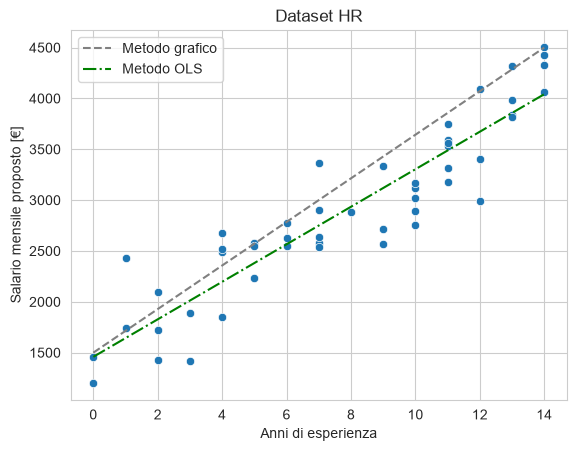

In [9]:
x_new_model = np.linspace(0,14)
y_new_model = polinomio(x_new_model)

sns.scatterplot(df,x='years_exp',y='salary')
sns.lineplot(x=x_graphic,y=y_graphic,linestyle='--', color='gray',label='Metodo grafico')
sns.lineplot(x=x_new_model,y=y_new_model,linestyle='-.', color='green',label='Metodo OLS')
plt.legend()
plt.title('Dataset HR')
plt.xlabel('Anni di esperienza')
plt.ylabel('Salario mensile proposto [€]')
plt.show()

In [10]:
y_pred_lin = polinomio(x_train)

print('REPORT MODELLO GRAFICO')
stampa_report_modello(y_train,y_pred_g)
print('-'*20)
print('REPORT MODELLO LINEARE')
stampa_report_modello(y_train,y_pred_lin)

REPORT MODELLO GRAFICO
MAE: 354.05
RMSE: 441.50
R^2 Score: 0.72
--------------------
REPORT MODELLO LINEARE
MAE: 261.01
RMSE: 322.09
R^2 Score: 0.85
